In [14]:
import pandas as pd
import numpy as np
import os

file_path = "datasets/madalena_processed_30min"

def feature_engineer(file_path):
    df = pd.read_csv(file_path)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed:')]    
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    df = df.sort_index()
    df['day_of_year'] = df.index.dayofyear
    df['season'] = df.index.month % 12 // 3
    df['month'] = df.index.month
    df['day_of_week'] = df.index.weekday
    df['hour'] = df.index.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 48)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 48)

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['is_weekend'] = (df.index.weekday >= 5).astype(int)
    df['energy_lag_48'] = df['total_energy'].shift(48).fillna(method='bfill')
    df['energy_lag_96'] = df['total_energy'].shift(96).fillna(method='bfill')
    df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')
    df['energy_diff'] = df['total_energy'].diff().fillna(method='bfill')
    df['max_energy'] = df['total_energy'].rolling(window=48).max().fillna(method='bfill')
    df['min_energy'] = df['total_energy'].rolling(window=48).min().fillna(method='bfill')
    df['energy_diff_daily'] = df['max_energy'] - df['min_energy'] 
    df['energy_rolling'] = df['total_energy'].rolling(window=24).mean().fillna(method='bfill')
    df['Tout_diff'] = df['Tout'].diff().fillna(method="bfill")
    df['Tout_lag_1'] = df['Tout'].shift(1).fillna(method='bfill')
    df['Tout_lag_2'] = df['Tout'].shift(2).fillna(method='bfill')
    df['energy_std_48'] = df['total_energy'].rolling(window=48).std().fillna(method='bfill')
    df['energy_spike'] = (df['total_energy'] > df['total_energy'].rolling(window=48).mean().fillna(method='bfill') + 3*df['total_energy'].rolling(window=48).std().fillna(method='bfill')).astype(float)
    df['rolling_max_3h'] = df['total_energy'].rolling(window=6).max().fillna(method='bfill')
    df['recent_spike'] = df['total_energy'].diff().abs().rolling(2).max() > 200

    return df

In [15]:
import torch
from torch.utils.data import TensorDataset, DataLoader


def create_mimo_sequences(data, input_len=96, output_len=48):
    X, y = [], []
    for i in range(len(data) - input_len - output_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len, 0]) 
        # spike_targets.append(spike_data[i+input_len:i+input_len+output_len])
    return np.array(X), np.array(y)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_20256\2884819306.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_48'] = df['total_energy'].shift(48).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_20256\2884819306.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_96'] = df['total_energy'].shift(96).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_20256\2884819306.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_20256\2884819306.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Us

Epoch 1, Loss: 0.2455, Val Loss: 0.1626
Epoch 2, Loss: 0.1534, Val Loss: 0.1320
Epoch 3, Loss: 0.1271, Val Loss: 0.1101
Epoch 4, Loss: 0.1078, Val Loss: 0.0915
Epoch 5, Loss: 0.0939, Val Loss: 0.0821
Epoch 6, Loss: 0.0871, Val Loss: 0.0783
Epoch 7, Loss: 0.0839, Val Loss: 0.0765
Epoch 8, Loss: 0.0821, Val Loss: 0.0756
Epoch 9, Loss: 0.0808, Val Loss: 0.0744
Epoch 10, Loss: 0.0797, Val Loss: 0.0739
Epoch 11, Loss: 0.0786, Val Loss: 0.0731
Epoch 12, Loss: 0.0777, Val Loss: 0.0722
Epoch 13, Loss: 0.0768, Val Loss: 0.0713
Epoch 14, Loss: 0.0758, Val Loss: 0.0705
Epoch 15, Loss: 0.0749, Val Loss: 0.0698
Epoch 16, Loss: 0.0742, Val Loss: 0.0690
Epoch 17, Loss: 0.0733, Val Loss: 0.0683
Epoch 18, Loss: 0.0725, Val Loss: 0.0678
Epoch 19, Loss: 0.0718, Val Loss: 0.0673
Epoch 20, Loss: 0.0713, Val Loss: 0.0667
Epoch 21, Loss: 0.0707, Val Loss: 0.0665
Epoch 22, Loss: 0.0703, Val Loss: 0.0660
Epoch 23, Loss: 0.0698, Val Loss: 0.0656
Epoch 24, Loss: 0.0694, Val Loss: 0.0654
Epoch 25, Loss: 0.0689, V

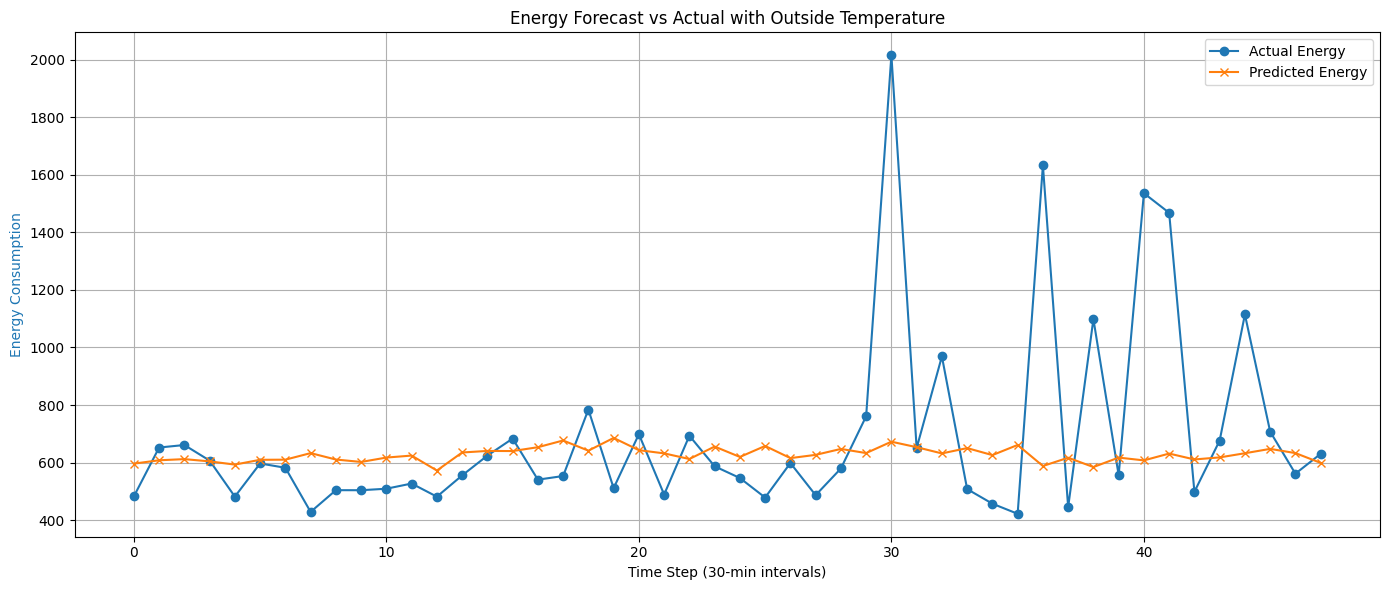

In [22]:
import torch.nn as nn
import matplotlib.pyplot as plt
import torch
import math
from sklearn.preprocessing import MinMaxScaler
import torch.nn.functional as F

class SpikeAwareLoss(nn.Module):
    def __init__(self, spike_threshold=350,  spike_weight=2.5):
        super().__init__()
        # self.alpha = alpha
        # self.beta = beta
        # self.gamma = gamma
        self.spike_weight = spike_weight
        self.spike_threshold = spike_threshold
        self.spike_weight = spike_weight

    def forward(self, pred, target, spike_mask):
        # mse = F.mse_loss(pred, target)

        mae = F.l1_loss(pred, target)
        # spike_diff = torch.abs(target[:, 1:] - target[:, :-1])
        # spike_mask = (spike_diff > 300).float()
        # target_mean = target.mean(dim=1, keepdim=True)
        # spike_mask = (target > target_mean).float()
        spike_mse = ((1 + spike_mask * 5.0) * (pred - target) ** 4).mean()
        # spike_mse = ( (pred - target) ** 4).mean()

        return mae + 2.0 * spike_mse
    # def __init__(self, spike_weight=3.0):
    #     super().__init__()
    #     self.spike_weight = spike_weight

    # def forward(self, pred, target, spike_mask):
    #     abs_error = torch.abs(pred - target)

    #     # Spike mask is 1 for spikes, 0 for non-spikes
    #     # weights = 1 + (self.spike_weight - 1) * spike_mask
    #     mse = F.mse_loss(pred, target)

    #     # weighted_mae = (weights * abs_error).mean()
    #     spike_weighted_error = ((1 + spike_mask * 4.0) * (pred - target) ** 4).mean()
    #     return mse + spike_weighted_error

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)].to(x.device)
        return x

class CNNLSTM(nn.Module):
    def __init__(self, input_size, d_model=128, nhead=8, num_layers=2, output_len=48):
        super(CNNLSTM, self).__init__()
        self.cnn = nn.Conv1d(in_channels=input_size, out_channels=128, kernel_size=3, padding=1)
        # self.tcn = TCN(input_size=input_size, num_channels=[64, 128], kernel_size=3)
        # self.cnn = nn.Sequential(
        #     nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=3, padding=1),
        #     nn.ReLU(),
        #     nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
        #     nn.ReLU()
        # )
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, output_len)
        )
        self.spike_fc = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, output_len),
            nn.Sigmoid()
        )


    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x = self.pos_encoder(x)
        x = self.transformer(x)  
        x_last = x[:, -1, :]        
        energy_pred = self.fc(x_last)
        spike_pred = self.spike_fc(x_last)
        return energy_pred, spike_pred

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


for file in os.listdir(file_path):
    full_path = os.path.join(file_path, file)
    if file != 'E_147.csv':
        continue
    df = feature_engineer(full_path)
    energy_diff = np.abs(df['total_energy'].values[1:] - df['total_energy'].values[:-1])
    spike_threshold = 350  
    spike_target = (energy_diff >= spike_threshold).astype(float)

    spike_target = np.concatenate([[0], spike_target])
    features = ['total_energy', 'energy_std_48', 'Tout', 'Tout_diff', 'Tout_lag_1',
                'month_sin', 'month_cos', 'day_of_week', 'hour_sin','hour_cos', 'is_weekend', 'energy_lag_48', 'max_energy', 'Tout_diff', 'recent_spike']
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[features])
    df[features] = scaled_data
    data = df[features].values

    X, y, spike_targets = create_mimo_sequences(data, spike_target)
    model = CNNLSTM(input_size=X.shape[2], d_model=128, output_len=48).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    spike_tensor = torch.tensor(spike_targets, dtype=torch.float32) 

    dataset = TensorDataset(X_tensor, y_tensor, spike_tensor)
    train_size = int(0.85 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    for epoch in range(60):
        model.train()
        total_loss = 0
        for xb, yb, spike_target in train_loader:
            xb, yb, spike_target = xb.to(device), yb.to(device), spike_target.to(device)
            optimizer.zero_grad()
            energy_pred, spike_pred = model(xb)
            # energy_diff = torch.abs(yb[:, 1:] - yb[:, :-1])
            # spike_threshold = 350.0
            # spike_target = (energy_diff >= spike_threshold).float()
            # spike_target = torch.cat([torch.zeros((yb.size(0), 1), device=yb.device), spike_target], dim=1)
            criterion = SpikeAwareLoss(spike_weight=4.5)
            # criterion = nn.L1Loss()
            energy_loss = criterion(energy_pred, yb.to(device), spike_target)
            spike_loss = F.binary_cross_entropy(spike_pred, spike_target)
            loss = energy_loss 
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        model.eval()
        all_preds, all_targets = [], []
        val_loss_total = 0
        with torch.no_grad():
            for xb, yb, spike_target in val_loader:
                xb, yb, spike_target = xb.to(device), yb.to(device), spike_target.to(device)               
                # energy_pred, spike_pred = model(xb).cpu().numpy()
                energy_pred, spike_pred = model(xb)
                criterion = SpikeAwareLoss(spike_weight=4.5)
                # criterion = nn.L1Loss()
                energy_loss = criterion(energy_pred, yb.to(device), spike_target)
                spike_loss = F.binary_cross_entropy(spike_pred, spike_target)
                loss = energy_loss
                val_loss_total += loss.item()
                energy_pred = energy_pred.cpu().numpy()

                all_preds.append(energy_pred)
                all_targets.append(yb.cpu().numpy())
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}, Val Loss: {val_loss_total / len(val_loader):.4f}")

    preds = np.concatenate(all_preds, axis=0)
    targets = np.concatenate(all_targets, axis=0)
    n_preds, n_steps = preds.shape
    n_features = len(features) 
    dummy = np.zeros((n_preds, n_steps, n_features - 1))
    preds_full = np.concatenate([preds[..., np.newaxis], dummy], axis=2) 
    targets_full = np.concatenate([targets[..., np.newaxis], dummy], axis=2)

    preds_flat = preds_full.reshape(-1, n_features)
    targets_flat = targets_full.reshape(-1, n_features)

    preds_inv = scaler.inverse_transform(preds_flat)[:, 0]   
    targets_inv = scaler.inverse_transform(targets_flat)[:, 0]

    preds = preds_inv.reshape(n_preds, n_steps)
    targets = targets_inv.reshape(n_preds, n_steps)

    mse = np.mean((preds - targets) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(preds - targets))

    print(f"✅ RMSE: {rmse:.4f}")
    print(f"✅ MAE:  {mae:.4f}")
    print(f"✅ MSE:  {mse:.4f}")
    sample_idx = 0  
    temperature_scaled = X_tensor[sample_idx, :, 1].numpy()
    dummy_temp = np.zeros((96, len(features)))
    dummy_temp[:, 1] = temperature_scaled 
    temp_inv = scaler.inverse_transform(dummy_temp)[:, 1]
    fig, ax1 = plt.subplots(figsize=(14, 6))
    steps = np.arange(48)

    plt.plot(steps, targets[sample_idx], label="Actual Energy", marker='o', color='tab:blue')
    plt.plot(steps, preds[sample_idx], label="Predicted Energy", marker='x', color='tab:orange')
    plt.ylabel("Energy Consumption", color='tab:blue')
    plt.xlabel("Time Step (30-min intervals)")
    # ax1.set_ylabel("Energy Consumption", color='tab:blue')
    # ax1.tick_params(axis='y', labelcolor='tab:blue')

    # ax2 = ax1.twinx()
    # ax2.plot(steps, temp_inv, label="Outside Temp (°C)", color='tab:green', linestyle='--')
    # ax2.set_ylabel("Temperature (°C)", color='tab:green')
    # ax2.tick_params(axis='y', labelcolor='tab:green')

    # lines, labels = ax1.get_legend_handles_labels()
    # lines2, labels2 = ax2.get_legend_handles_labels()
    # ax1.legend(lines + lines2, labels + labels2, loc='upper right')
    plt.legend()
    plt.title("Energy Forecast vs Actual with Outside Temperature")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    break


✅ RMSE: 219.7135
✅ MAE:  125.1458
✅ MSE:  48274.0098


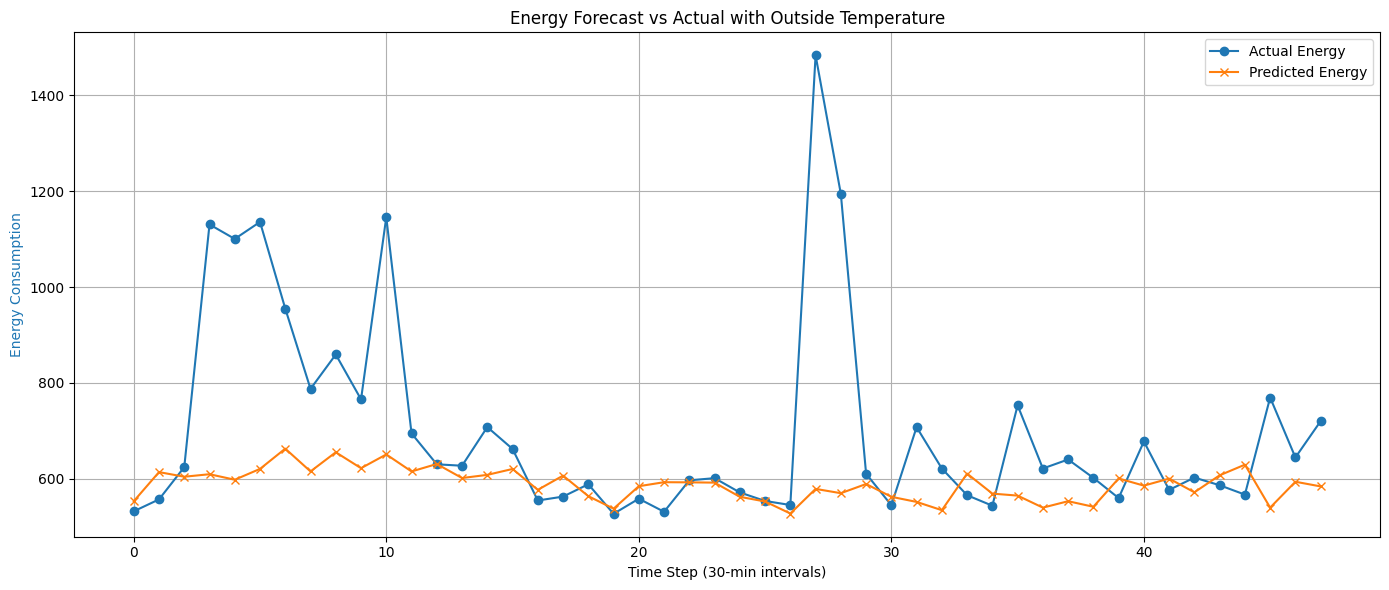

In [21]:
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
     with torch.no_grad():
        for xb, yb, spike_target in val_loader:
            xb = xb.to(device)
            # energy_pred, spike_pred = model(xb).cpu().numpy()
            energy_pred,spike = model(xb)
            energy_pred = energy_pred.cpu().numpy()
            all_preds.append(energy_pred)
            all_targets.append(yb.numpy())

    # for xb, yb in val_loader:
    #     xb = xb.to(device)
    #     energy_pred, spike_pred = model(xb)
    #     energy_pred = energy_pred.cpu().numpy()
    #     all_preds.append(energy_pred)
    #     all_targets.append(yb.numpy())

preds = np.concatenate(all_preds, axis=0)
targets = np.concatenate(all_targets, axis=0)
n_preds, n_steps = preds.shape
n_features = len(features) 
dummy = np.zeros((n_preds, n_steps, n_features - 1))
preds_full = np.concatenate([preds[..., np.newaxis], dummy], axis=2) 
targets_full = np.concatenate([targets[..., np.newaxis], dummy], axis=2)

preds_flat = preds_full.reshape(-1, n_features)
targets_flat = targets_full.reshape(-1, n_features)

preds_inv = scaler.inverse_transform(preds_flat)[:, 0]   
targets_inv = scaler.inverse_transform(targets_flat)[:, 0]

preds = preds_inv.reshape(n_preds, n_steps)
targets = targets_inv.reshape(n_preds, n_steps)

mse = np.mean((preds - targets) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(preds - targets))

print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE:  {mae:.4f}")
print(f"✅ MSE:  {mse:.4f}")
sample_idx = 6
temperature_scaled = X_tensor[sample_idx, :, 1].numpy()
dummy_temp = np.zeros((96, len(features)))
dummy_temp[:, 1] = temperature_scaled 
temp_inv = scaler.inverse_transform(dummy_temp)[:, 1]
fig, ax1 = plt.subplots(figsize=(14, 6))
steps = np.arange(48)

plt.plot(steps, targets[sample_idx], label="Actual Energy", marker='o', color='tab:blue')
plt.plot(steps, preds[sample_idx], label="Predicted Energy", marker='x', color='tab:orange')
plt.ylabel("Energy Consumption", color='tab:blue')
plt.xlabel("Time Step (30-min intervals)")
# ax1.set_ylabel("Energy Consumption", color='tab:blue')
# ax1.tick_params(axis='y', labelcolor='tab:blue')

# ax2 = ax1.twinx()
# ax2.plot(steps, temp_inv, label="Outside Temp (°C)", color='tab:green', linestyle='--')
# ax2.set_ylabel("Temperature (°C)", color='tab:green')
# ax2.tick_params(axis='y', labelcolor='tab:green')

# lines, labels = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines + lines2, labels + labels2, loc='upper right')
plt.legend()
plt.title("Energy Forecast vs Actual with Outside Temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

In [190]:
sample_idx = 3
 
temperature_scaled = X_tensor[sample_idx, :, 1].numpy()
dummy_temp = np.zeros((336, len(features)))
dummy_temp[:, 1] = temperature_scaled 
temp_inv = scaler.inverse_transform(dummy_temp)[:, 1]
fig, ax1 = plt.subplots(figsize=(14, 6))
steps = np.arange(48)

ax1.plot(steps, targets[sample_idx], label="Actual Energy", marker='o', color='tab:blue')
ax1.plot(steps, preds[sample_idx], label="Predicted Energy", marker='x', color='tab:orange')
ax1.set_xlabel("Time Step (30-min intervals)")
ax1.set_ylabel("Energy Consumption", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(steps, temp_inv, label="Outside Temp (°C)", color='tab:green', linestyle='--')
ax2.set_ylabel("Temperature (°C)", color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title("Energy Forecast vs Actual with Outside Temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

ValueError: could not broadcast input array from shape (96,) into shape (336,)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7592\2884819306.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_48'] = df['total_energy'].shift(48).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7592\2884819306.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_96'] = df['total_energy'].shift(96).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7592\2884819306.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7592\2884819306.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use ob

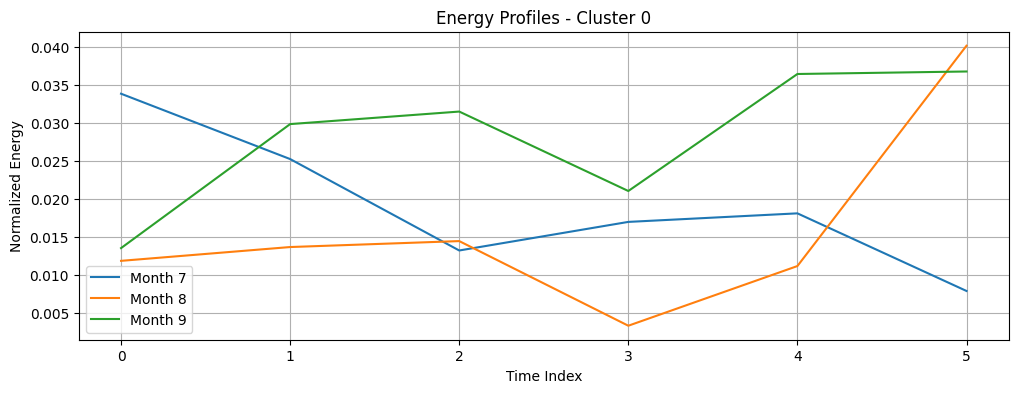

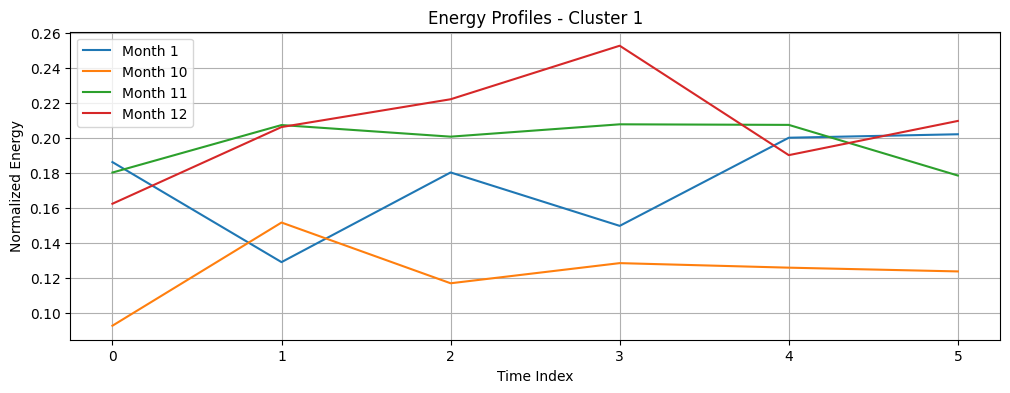

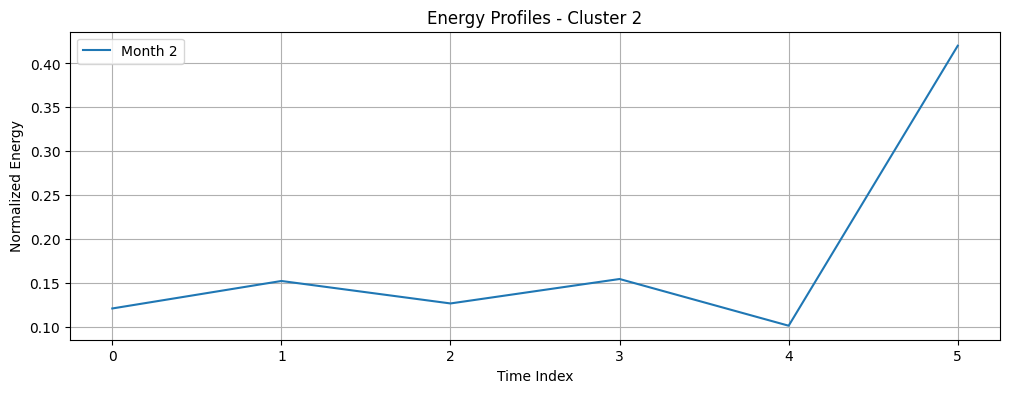

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7592\1285737230.py:60: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['rolling_mean_6'] = df['total_energy'].rolling(6).mean().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7592\1285737230.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['rolling_std_6'] = df['total_energy'].rolling(6).std().fillna(method='bfill')


Epoch 1/200 | Train Loss: 0.010904 | Val Loss: 0.009260
Epoch 2/200 | Train Loss: 0.008692 | Val Loss: 0.008414
Epoch 3/200 | Train Loss: 0.008572 | Val Loss: 0.008308
Epoch 4/200 | Train Loss: 0.008185 | Val Loss: 0.008066
Epoch 5/200 | Train Loss: 0.008027 | Val Loss: 0.007865
Epoch 6/200 | Train Loss: 0.007892 | Val Loss: 0.007963
Epoch 7/200 | Train Loss: 0.007781 | Val Loss: 0.007740
Epoch 8/200 | Train Loss: 0.007669 | Val Loss: 0.007648
Epoch 9/200 | Train Loss: 0.007652 | Val Loss: 0.007560
Epoch 10/200 | Train Loss: 0.007480 | Val Loss: 0.007420
Epoch 11/200 | Train Loss: 0.007480 | Val Loss: 0.007411
Epoch 12/200 | Train Loss: 0.007272 | Val Loss: 0.007152
Epoch 13/200 | Train Loss: 0.007155 | Val Loss: 0.007133
Epoch 14/200 | Train Loss: 0.007090 | Val Loss: 0.006960
Epoch 15/200 | Train Loss: 0.006893 | Val Loss: 0.006823
Epoch 16/200 | Train Loss: 0.006790 | Val Loss: 0.006713
Epoch 17/200 | Train Loss: 0.006537 | Val Loss: 0.006434
Epoch 18/200 | Train Loss: 0.006361 | Va

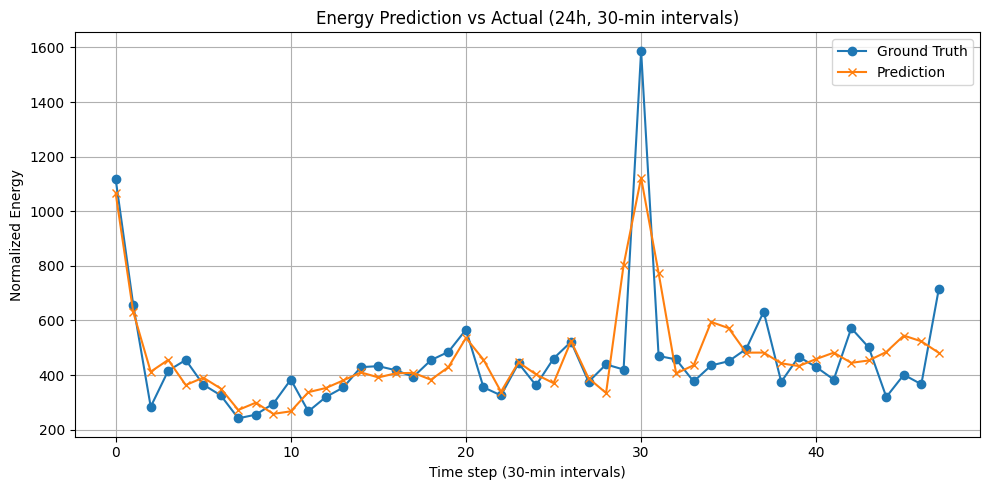

In [59]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def denormalize(norm_vals, original_min, original_max):
    return norm_vals * (original_max - original_min) + original_min

for file in os.listdir(file_path):
    full_path = os.path.join(file_path, file)
    if file != 'E_147.csv':
        continue
    df = feature_engineer(full_path)
    energy_min = df['total_energy'].min()
    energy_max = df['total_energy'].max()
    temp_min = df['Tout'].min()
    temp_max = df['Tout'].max()
    for col in ['total_energy', 'Tout']:
        min_val = df[col].min()
        max_val = df[col].max()
        df[col] = (df[col] - min_val) / (max_val - min_val)
    monthly_groups = df['total_energy'].groupby(df.index.month)

    min_len = min(len(group) for _, group in monthly_groups)

    monthly_profiles = np.vstack([
        group.values[:min_len] for _, group in monthly_groups
    ])

    k = 3
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(monthly_profiles)
    available_months = sorted(df.index.month.unique())
    month_cluster_map = dict(zip(available_months, clusters))
    df['cluster'] = df.index.month.map(month_cluster_map)
    for cluster_id in np.unique(clusters):
        cluster_months = [m for m, c in month_cluster_map.items() if c == cluster_id]
        plt.figure(figsize=(12, 4))
        
        for m in cluster_months:
            energy = df[df.index.month == m]['total_energy'].values[:min_len]  # trunc to min_len
            plt.plot(energy, label=f'Month {m}')
        
        plt.title(f'Energy Profiles - Cluster {cluster_id}')
        plt.xlabel('Time Index')
        plt.ylabel('Normalized Energy')
        plt.legend()
        plt.grid(True)
        plt.show()

    features = ['total_energy', 'Tout', 'month_sin', 'month_cos', 'day_of_week', 'hour_sin', 'hour_cos', 'is_weekend', 'cluster', 'energy_lag_48', 'energy_diff', 'max_energy', 'rolling_mean_6', 'rolling_std_6']
    df['rolling_mean_6'] = df['total_energy'].rolling(6).mean().fillna(method='bfill')
    df['rolling_std_6'] = df['total_energy'].rolling(6).std().fillna(method='bfill')

    df['energy_lag_48'] = (df['energy_lag_48'] - energy_min) / (energy_max - energy_min)
    df['energy_diff'] = (df['energy_diff'] - energy_min) / (energy_max - energy_min)
    df['max_energy'] = (df['max_energy'] - energy_min) / (energy_max - energy_min)
    df['Tout_diff'] = (df['Tout_diff'] - temp_min) / (temp_max - temp_min)
    df['rolling_std_6'] = (df['rolling_std_6'] - energy_min) / (energy_max - energy_min)
    df['rolling_mean_6'] = (df['rolling_mean_6'] - energy_min) / (energy_max - energy_min)
    data = df[features].values
    X, y = create_mimo_sequences(data, input_len=48)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

    train_ds = TensorDataset(X_train_tensor, y_train_tensor)
    test_ds = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
    class KCNNLSTM(nn.Module):
        def __init__(self, input_features, conv_out=128, lstm_hidden=128, output_len=48):
            super(KCNNLSTM, self).__init__()
            self.conv = nn.Conv1d(input_features, conv_out, kernel_size=2, padding='same')
            self.relu = nn.ReLU()
            self.lstm = nn.LSTM(conv_out, lstm_hidden, batch_first=True)
            self.fc1 = nn.Linear(lstm_hidden, 32)
            self.fc2 = nn.Linear(32, output_len)

        def forward(self, x):
            x = x.permute(0, 2, 1)  
            x = self.conv(x)
            x = self.relu(x)
            x = x.permute(0, 2, 1)  
            lstm_out, _ = self.lstm(x)
            x = lstm_out[:, -1, :]
            x = self.fc1(x)
            x = self.fc2(x)
            return x
        
    model = KCNNLSTM(input_features=X_train.shape[2]).to(device)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0015)

    n_epochs = 200
    for epoch in range(n_epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            optimizer.zero_grad()
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = loss_fn(preds, yb)
                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb) 
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())
        sample_idx = 0
        true_vals = yb[sample_idx].cpu().numpy()
        pred_vals = preds[sample_idx].cpu().numpy()
        y_pred = np.concatenate(all_preds, axis=0)
        y_true = np.concatenate(all_targets, axis=0)
        y_true = denormalize(y_true, energy_min, energy_max)
        y_pred = denormalize(y_pred, energy_min, energy_max)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        print(f"\n🔍 Final Evaluation on Test Set:")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        plt.figure(figsize=(10, 5))
        true_vals = denormalize(true_vals, energy_min, energy_max)
        pred_vals = denormalize(pred_vals, energy_min, energy_max)
        plt.plot(true_vals, label='Ground Truth', marker='o')
        plt.plot(pred_vals, label='Prediction', marker='x')
        plt.title("Energy Prediction vs Actual (24h, 30-min intervals)")
        plt.xlabel("Time step (30-min intervals)")
        plt.ylabel("Normalized Energy")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()